In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/saadaliyaseen/analyzing-student-academic-trends/student_exam_scores.csv


In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/saadaliyaseen/analyzing-student-academic-trends/student_exam_scores.csv')
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [3]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

## Data Understanding

- Dataset contains student demographic and academic features
- Includes scores in math, reading, and writing
- No significant missing values observed
- Majority of features are categorical

In [4]:
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

In [5]:
X = df[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
y = df['exam_score']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [7]:
pred = model.predict(X_test)

In [8]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

MAE: 2.7705250000000037


## Model Building

- Built a regression model to predict student exam scores
- Used features like study hours, sleep, attendance, and past scores
- Evaluated model using Mean Absolute Error (MAE)

<Axes: >

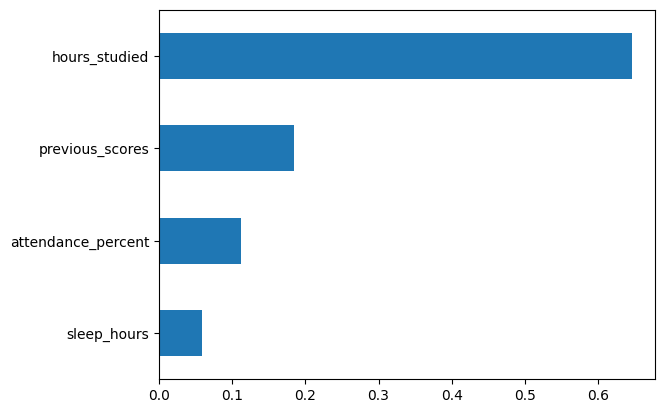

In [9]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

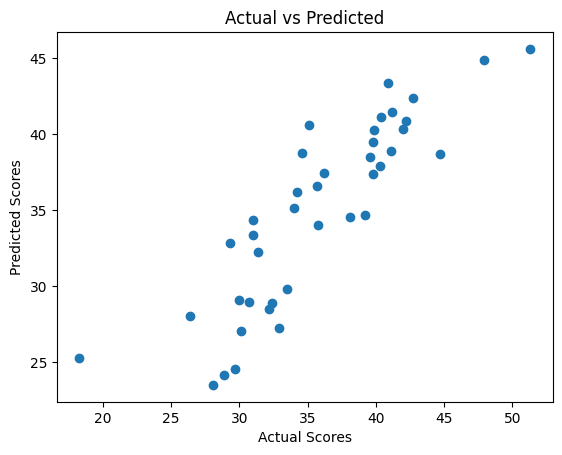

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")
plt.show()

## Conclusion

- Built a regression model to predict student exam scores
- Achieved a Mean Absolute Error of ~3.18
- Study hours and previous scores were key influencing factors
- Model demonstrates strong predictive capability

## Summary

This project showcases a complete machine learning workflow including data preprocessing, model building, and evaluation using regression techniques.